In [294]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statstests.process import stepwise
from scipy.stats import shapiro #teste de Shapiro-Wilk
from scipy import stats #testes estatísticos
from statsmodels.stats.outliers_influence import variance_inflation_factor #diagnóstico de multicolinearidade
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

In [295]:
df = pd.read_excel('dataset.xlsx')  

## Análise Exploratoria

In [296]:
df

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg
0,20,300C/SRT-8,C,253,4,9.9,3.07,30.9,0.011,288,30.8
1,20,CARAVAN 2WD,T,180,F,9.3,2.49,32.3,0.014,274,32.5
2,20,CROSSFIRE ROADSTER,C,168,R,10.0,3.27,37.1,0.001,250,35.4
3,20,DAKOTA PICKUP 2WD,T,210,R,9.2,3.55,29.6,0.012,316,28.1
4,20,DAKOTA PICKUP 4WD,T,210,4,9.2,3.55,29.6,0.011,365,24.4
5,20,DURANGO 2WD,T,345,R,8.6,3.55,27.2,0.023,367,24.1
6,20,GRAND CHEROKEE 2WD,T,210,R,9.2,3.07,30.4,0.006,312,28.5
7,20,GRAND CHEROKEE 4WD,T,230,4,9.0,3.07,24.7,0.008,369,24.2
8,20,LIBERTY/CHEROKEE 2WD,T,150,R,9.5,4.10,41.0,0.004,270,32.8
9,20,LIBERTY/CHEROKEE 4WD,T,210,4,9.2,3.73,31.2,0.003,317,NaN


In [297]:
df.describe()

,cfab,PM,rc,re,vmvv,HC,co2,mpg
count,21.0,21.000000,20.00000,21.000000,21.000000,21.000000,21.000000,19.000000
mean,20.0,239.476190,9.42000,3.220000,32.400000,0.008476,291.000000,29.389474
std,0.0,103.410163,0.39683,0.503061,5.829494,0.007387,88.754155,5.905825
min,20.0,132.000000,8.60000,2.490000,19.400000,0.000000,0.000000,18.700000
25%,20.0,168.000000,9.20000,2.690000,29.600000,0.003000,260.000000,25.150000
50%,20.0,210.000000,9.50000,3.070000,32.300000,0.007000,295.000000,28.500000
75%,20.0,249.000000,9.65000,3.550000,36.800000,0.011000,337.000000,33.300000
max,20.0,501.000000,10.00000,4.100000,41.000000,0.024000,474.000000,41.300000


In [298]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cfab             21 non-null     int64  
 1   Modelo do carro  21 non-null     str    
 2   tipo             21 non-null     str    
 3   PM               21 non-null     int64  
 4   csd              21 non-null     object 
 5   rc               20 non-null     float64
 6   re               21 non-null     float64
 7   vmvv             21 non-null     float64
 8   HC               21 non-null     float64
 9   co2              21 non-null     int64  
 10  mpg              19 non-null     float64
dtypes: float64(5), int64(3), object(1), str(2)
memory usage: 1.9+ KB


### Dados Ausentes

In [299]:
invalid_mpg = df[df['mpg'].isnull()]
df = df.dropna(subset=['mpg'])
print(invalid_mpg)

    cfab       Modelo do carro tipo   PM csd   rc    re  vmvv     HC  co2  mpg
9     20  LIBERTY/CHEROKEE 4WD    T  210   4  9.2  3.73  31.2  0.003  317  NaN
13    20            PT CRUISER    T  220   F  9.5  2.69  37.3  0.002  260  NaN


In [300]:
df[df['rc'].isnull()]

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg
16,20,SEBRING 4-DR,C,200,F,NaN,2.69,36.8,0.011,252,35.1


In [301]:
rc_mean = df[df['rc'].notnull()]['rc'].mean()
rc_mean
df.loc[df['rc'].isnull(), 'rc'] = rc_mean


### Dados Incorretos

In [302]:
df['co2'].describe()

count     19.000000
mean     291.263158
std       93.067384
min        0.000000
25%      257.000000
50%      295.000000
75%      339.500000
max      474.000000
Name: co2, dtype: float64

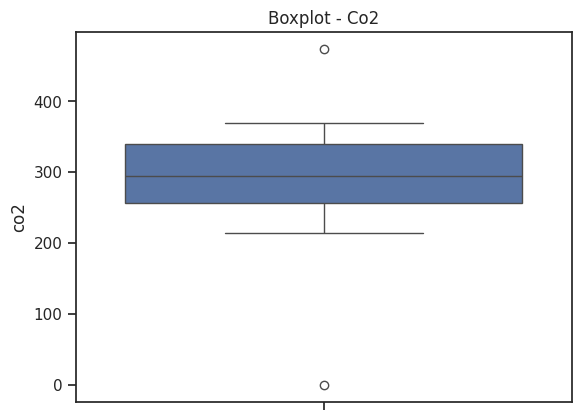

In [303]:
sns.boxplot(y=df["co2"])
plt.title("Boxplot - Co2")
plt.show()

Cálculo da média da variável sem o dado zerado e substuindo-o pela média calculada:

In [304]:
co2_mean = int(round(df[df['co2'] != 0]['co2'].mean()))
df.loc[df['co2'] == 0, 'co2'] = co2_mean
print(co2_mean)

307


In [305]:
df['co2'].describe()

count     19.000000
mean     307.421053
std       60.718216
min      214.000000
25%      266.000000
50%      307.000000
75%      339.500000
max      474.000000
Name: co2, dtype: float64

In [306]:
df.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cfab             19 non-null     int64  
 1   Modelo do carro  19 non-null     str    
 2   tipo             19 non-null     str    
 3   PM               19 non-null     int64  
 4   csd              19 non-null     object 
 5   rc               19 non-null     float64
 6   re               19 non-null     float64
 7   vmvv             19 non-null     float64
 8   HC               19 non-null     float64
 9   co2              19 non-null     int64  
 10  mpg              19 non-null     float64
dtypes: float64(5), int64(3), object(1), str(2)
memory usage: 1.8+ KB


In [307]:
df.describe()

,cfab,PM,rc,re,vmvv,HC,co2,mpg
count,19.0,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,20.0,242.052632,9.427778,3.221053,32.205263,0.009105,307.421053,29.389474
std,0.0,108.653104,0.403878,0.501131,6.025361,0.007497,60.718216,5.905825
min,20.0,132.000000,8.600000,2.490000,19.400000,0.000000,214.000000,18.700000
25%,20.0,167.500000,9.200000,2.820000,29.300000,0.003500,266.000000,25.150000
50%,20.0,210.000000,9.500000,3.070000,32.300000,0.008000,307.000000,28.500000
75%,20.0,251.000000,9.700000,3.550000,36.800000,0.011500,339.500000,33.300000
max,20.0,501.000000,10.000000,4.100000,41.000000,0.024000,474.000000,41.300000


### Removendo Colunas

In [308]:
df

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg
0,20,300C/SRT-8,C,253,4,9.900000,3.07,30.9,0.011,288,30.8
1,20,CARAVAN 2WD,T,180,F,9.300000,2.49,32.3,0.014,274,32.5
2,20,CROSSFIRE ROADSTER,C,168,R,10.000000,3.27,37.1,0.001,250,35.4
3,20,DAKOTA PICKUP 2WD,T,210,R,9.200000,3.55,29.6,0.012,316,28.1
4,20,DAKOTA PICKUP 4WD,T,210,4,9.200000,3.55,29.6,0.011,365,24.4
5,20,DURANGO 2WD,T,345,R,8.600000,3.55,27.2,0.023,367,24.1
6,20,GRAND CHEROKEE 2WD,T,210,R,9.200000,3.07,30.4,0.006,312,28.5
7,20,GRAND CHEROKEE 4WD,T,230,4,9.000000,3.07,24.7,0.008,369,24.2
8,20,LIBERTY/CHEROKEE 2WD,T,150,R,9.500000,4.10,41.0,0.004,270,32.8
10,20,NEON/SRT-4/SX 2.0,C,132,F,9.800000,2.69,39.2,0.003,214,41.3


In [309]:
df_tratado = df
df = df.drop(columns=['Modelo do carro', 'cfab'])

In [310]:
df.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tipo    19 non-null     str    
 1   PM      19 non-null     int64  
 2   csd     19 non-null     object 
 3   rc      19 non-null     float64
 4   re      19 non-null     float64
 5   vmvv    19 non-null     float64
 6   HC      19 non-null     float64
 7   co2     19 non-null     int64  
 8   mpg     19 non-null     float64
dtypes: float64(5), int64(2), object(1), str(1)
memory usage: 1.5+ KB


### Dummização

In [311]:
df.groupby('tipo').size()

tipo
C     6
T    13
dtype: int64

In [312]:
df.groupby('csd').size()

csd
4    6
F    6
R    7
dtype: int64

In [313]:
df = pd.get_dummies(df, columns=['tipo', 'csd'], drop_first=False, dtype=int)
del df['tipo_T']
del df['csd_R']
df.head()

,PM,rc,re,vmvv,HC,co2,mpg,tipo_C,csd_4,csd_F
0,253,9.9,3.07,30.9,0.011,288,30.8,1,1,0
1,180,9.3,2.49,32.3,0.014,274,32.5,0,0,1
2,168,10.0,3.27,37.1,0.001,250,35.4,1,0,0
3,210,9.2,3.55,29.6,0.012,316,28.1,0,0,0
4,210,9.2,3.55,29.6,0.011,365,24.4,0,1,0


## Modelo de Regressão

In [314]:
df.head()

,PM,rc,re,vmvv,HC,co2,mpg,tipo_C,csd_4,csd_F
0,253,9.9,3.07,30.9,0.011,288,30.8,1,1,0
1,180,9.3,2.49,32.3,0.014,274,32.5,0,0,1
2,168,10.0,3.27,37.1,0.001,250,35.4,1,0,0
3,210,9.2,3.55,29.6,0.012,316,28.1,0,0,0
4,210,9.2,3.55,29.6,0.011,365,24.4,0,1,0


In [315]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM      19 non-null     int64  
 1   rc      19 non-null     float64
 2   re      19 non-null     float64
 3   vmvv    19 non-null     float64
 4   HC      19 non-null     float64
 5   co2     19 non-null     int64  
 6   mpg     19 non-null     float64
 7   tipo_C  19 non-null     int64  
 8   csd_4   19 non-null     int64  
 9   csd_F   19 non-null     int64  
dtypes: float64(5), int64(5)
memory usage: 1.6 KB


In [316]:
# Variáveis independentes
x = df.drop(['mpg'],axis=1)

# Variável dependentes
y = df['mpg']

In [317]:
x.head()

,PM,rc,re,vmvv,HC,co2,tipo_C,csd_4,csd_F
0,253,9.9,3.07,30.9,0.011,288,1,1,0
1,180,9.3,2.49,32.3,0.014,274,0,0,1
2,168,10.0,3.27,37.1,0.001,250,1,0,0
3,210,9.2,3.55,29.6,0.012,316,0,0,0
4,210,9.2,3.55,29.6,0.011,365,0,1,0


In [318]:
y.head()

0    30.8
1    32.5
2    35.4
3    28.1
4    24.4
Name: mpg, dtype: float64

In [319]:
model=(sm.OLS(y,sm.add_constant(x)).fit())
model.summary(title='Sumario')

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   Sumario                                    
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     41.84
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.81e-06
Time:                        19:41:17   Log-Likelihood:                -24.493
No. Observations:                  19   AIC:                             68.99
Df Residuals:                       9   BIC:                             78.43
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.2964      9.348      2.706      0.024       4.149      46.444
PM            -0.0221      0.008     -2.909      0.017      -0.039      -0.005
rc             1.8946      1.129      1.679      0.127      -0.658       4.448
re            -1.1810      1.674     -0.706      0.498      -4.967       2.605
vmvv           0.0584      0.173      0.337      0.744      -0.334       0.451
HC            13.9433     54.557      0.256      0.804    -109.474     137.360
co2           -0.0227      0.014     -1.679      0.128      -0.053       0.008
tipo_C         3.5024      1.072      3.266      0.010       1.077       5.928
csd_4         -3.0966      0.790     -3.918      0.004      -4.885      -1.309
csd_F          0.6693      1.361      0.492      0.635      -2.410       3.749
==============================================================================
Omnibus:                        0.204   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.903   Jarque-Bera (JB):                0.387
Skew:                           0.166   Prob(JB):                        0.824
Kurtosis:                       2.385   Cond. No.                     7.57e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.57e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<p>O primeiro modelo obtido foi:</p>
<p>mpg = -0.0220*PM + 1.8939*rc - 1.1767*re + 0.0581*vmvv + 13.9079*HC - 0.0228*co2 + 3.4992*tipo_C - 3.0931*csd_4 + 0.6716*csd_F`

Analisando a tabela, chegamos as seguintes conclusões sobre o modelo:

- O coeficiente de determinação é de 0.977, isto é, 97.7% da variação da variável **mpg** é respondida pela variação das variáveis dependentes.

- O Prob(F-statistic) é de 2.80e-06. Como o valor é < 0.05, o modelo é significativo. Isto é, ao menos um dos parâmetros beta são significativos.

In [320]:
model_confs = model.conf_int(alpha=0.05)
model_confs.columns = ['lower_bound', 'upper_bound']
model_confs

,lower_bound,upper_bound
const,4.148817,46.443982
PM,-0.039211,-0.004904
rc,-0.658212,4.447509
re,-4.967149,2.605089
vmvv,-0.333872,0.450662
HC,-109.473776,137.360356
co2,-0.053251,0.007887
tipo_C,1.076661,5.928119
csd_4,-4.884573,-1.308702
csd_F,-2.410125,3.748757


In [321]:
print("Intervalo de confiança de 95% para os coeficientes do modelo:")
not_significant = []
for conf in model_confs.itertuples():
    print(f"{conf.Index}: [{conf[1]:.4f}, {conf[2]:.4f}] -> {'Significativo' if conf[1] > 0 or conf[2] < 0 else 'Não significativo'}")
    if conf[1] <= 0 and conf[2] >= 0:
        not_significant.append(conf.Index)

Intervalo de confiança de 95% para os coeficientes do modelo:
const: [4.1488, 46.4440] -> Significativo
PM: [-0.0392, -0.0049] -> Significativo
rc: [-0.6582, 4.4475] -> Não significativo
re: [-4.9671, 2.6051] -> Não significativo
vmvv: [-0.3339, 0.4507] -> Não significativo
HC: [-109.4738, 137.3604] -> Não significativo
co2: [-0.0533, 0.0079] -> Não significativo
tipo_C: [1.0767, 5.9281] -> Significativo
csd_4: [-4.8846, -1.3087] -> Significativo
csd_F: [-2.4101, 3.7488] -> Não significativo


## Procedimento StepWise


A função a seguir, fará o processo de step wise da seguinte forma, a cada iteração será checado qual das variaveis terá o maior p_value, após isso ela será retirada e o modelo será retestado, até acabar variaveis com intervalo de confiança maiores que 95%.

In [322]:
stepwise_model = stepwise(model, pvalue_limit=0.05)

# Parâmetros do 'stepwise_model' (output já obtido no código anterior)
stepwise_model.summary()

Regression type: OLS 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('vmvv') + Q('HC') + Q('co2') + Q('tipo_C') + Q('csd_4') + Q('csd_F')

 Discarding atribute "Q('HC')" with p-value equal to 0.8040266117945268 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('vmvv') + Q('co2') + Q('tipo_C') + Q('csd_4') + Q('csd_F')

 Discarding atribute "Q('csd_F')" with p-value equal to 0.6587947625337649 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('vmvv') + Q('co2') + Q('tipo_C') + Q('csd_4')

 Discarding atribute "Q('vmvv')" with p-value equal to 0.38269441058818854 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('co2') + Q('tipo_C') + Q('csd_4')

 Discarding atribute "Q('re')" with p-value equal to 0.0659247241596298 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('co2') + Q('tipo_C') + Q('csd_4')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('HC')", 'p-value': np.flo

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     72.54
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           4.95e-09
Time:                        19:41:17   Log-Likelihood:                -28.233
No. Observations:                  19   AIC:                             68.47
Df Residuals:                      13   BIC:                             74.13
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      22.6883      8.418      2.695      0.018       4.503      40.873
Q('PM')        -0.0236      0.005     -4.716      0.000      -0.034      -0.013
Q('rc')         2.3702      0.879      2.697      0.018       0.472       4.269
Q('co2')       -0.0322      0.010     -3.085      0.009      -0.055      -0.010
Q('tipo_C')     3.3593      0.973      3.453      0.004       1.257       5.461
Q('csd_4')     -3.3906      0.695     -4.880      0.000      -4.892      -1.890
==============================================================================
Omnibus:                        0.154   Durbin-Watson:                   2.247
Prob(Omnibus):                  0.926   Jarque-Bera (JB):                0.307
Skew:                          -0.172   Prob(JB):                        0.858
Kurtosis:                       2.480   Cond. No.                     1.16e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [323]:
print(f"Dos {len(model.params)} parâmetros do modelo original, {len(not_significant)} foram declarados não signficativos e preparados para remoção no stepwise.")
print("No entanto, os seguintes parâmetros se tornaram significativos após o processo stepwise:")
for param in stepwise_model.params.index:
    param = param.replace("Q('", '').replace("')", '')
    if param in not_significant:
        print(f"- Parâmetro '{param}' se tornou significativo.")

Dos 10 parâmetros do modelo original, 6 foram declarados não signficativos e preparados para remoção no stepwise.
No entanto, os seguintes parâmetros se tornaram significativos após o processo stepwise:
- Parâmetro 'rc' se tornou significativo.
- Parâmetro 'co2' se tornou significativo.


## Testes

### Normalidade dos resíduos

In [324]:
# Teste de Shapiro-Wilk (já que o tamanho da amostra é menor que 30)
stat, p = shapiro(stepwise_model.resid)

# Interpretação
print('Statistics=%.5f, p-value=%.4f' % (stat, p))
alpha = 0.05 #nível de significância
if p > alpha:
	print('Não se rejeita H0')
else:
	print('Rejeita-se H0')

Statistics=0.98059, p-value=0.9490
Não se rejeita H0


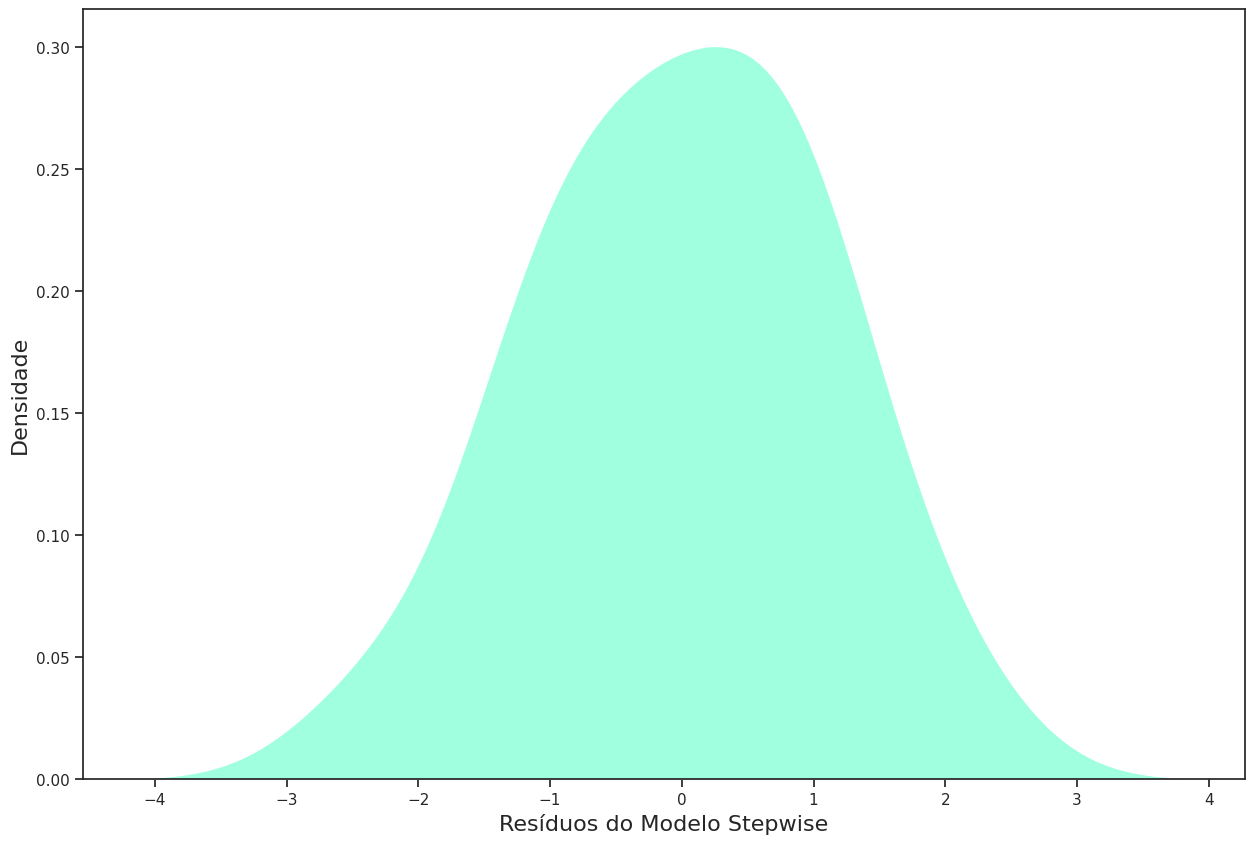

In [325]:
plt.figure(figsize=(15,10))
sns.kdeplot(data=stepwise_model.resid, multiple="stack",
            color='aquamarine')
plt.xlabel('Resíduos do Modelo Stepwise', fontsize=16)
plt.ylabel('Densidade', fontsize=16)
plt.show()

### Multicolinearidade

#### Modelo Completo

In [326]:
X1 = df.drop(columns='mpg')

X1 = sm.add_constant(X1)

vif1 = pd.Series(
    [variance_inflation_factor(X1.values, i)
     for i in range(X1.shape[1])],
    index=X1.columns
)

tolerance1 = 1 / vif1

vif_tolerance = pd.concat([vif1, tolerance1],
          axis=1,
          keys=['VIF', 'Tolerance'])
vif_tolerance

,VIF,Tolerance
const,1019.746764,0.000981
PM,7.503753,0.133267
rc,2.296381,0.435468
re,7.776437,0.128594
vmvv,12.067572,0.082867
HC,1.849515,0.540682
co2,7.441995,0.134373
tipo_C,2.898964,0.344951
csd_4,1.574933,0.634948
csd_F,4.671993,0.214041


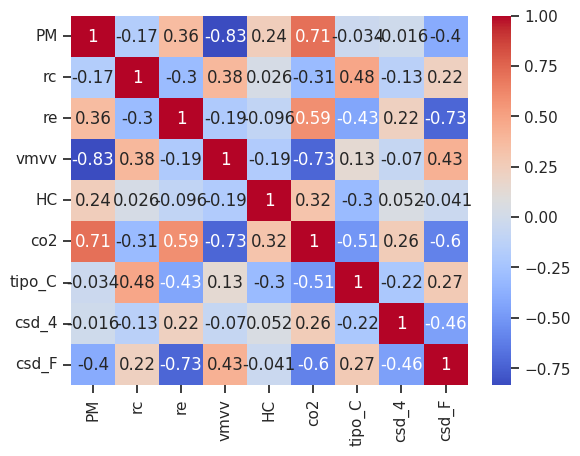

In [327]:
corr = X1.drop(columns='const').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [328]:
print("Variáveis com possível multicolinearidade (VIF):\n")

for variavel, valor in vif1.items():

    if variavel != 'const':

        if valor >10:
            nivel = "SEVERA"
        elif valor > 5 and valor <= 10:
            nivel = "ALTA"

        elif valor <=5 and valor > 1:
            nivel = "MODERADA"

        elif valor <= 1.001:   #Esta assim para evitar erros de arredondamento
            nivel = "NENHUMA"
        elif valor < 0.99:
            nivel = "VALOR INESPERADO" #Mesmo esquema aqui
        else:
            nivel = "Erro no processamento!"

        print(f"{variavel}: VIF = {valor:.2f} --> {nivel}")

Variáveis com possível multicolinearidade (VIF):

PM: VIF = 7.50 --> ALTA
rc: VIF = 2.30 --> MODERADA
re: VIF = 7.78 --> ALTA
vmvv: VIF = 12.07 --> SEVERA
HC: VIF = 1.85 --> MODERADA
co2: VIF = 7.44 --> ALTA
tipo_C: VIF = 2.90 --> MODERADA
csd_4: VIF = 1.57 --> MODERADA
csd_F: VIF = 4.67 --> MODERADA


#### Modelo após stepwise

In [329]:
X2 = df[['PM', 'rc', 'co2', 'tipo_C', 'csd_4']]
X2 = sm.add_constant(X2)

vif2 = pd.Series(
    [variance_inflation_factor(X2.values, i)
     for i in range(X2.shape[1])],
    index=X2.columns
)

tolerance2 = 1 / vif2
vif_tolerance2 = pd.concat([vif2, tolerance2], axis=1, keys=['VIF', 'Tolerance'])
vif_tolerance2

,VIF,Tolerance
const,805.615459,0.001241
PM,3.196759,0.312817
rc,1.356639,0.737116
co2,4.336399,0.230606
tipo_C,2.325462,0.430022
csd_4,1.185927,0.843222


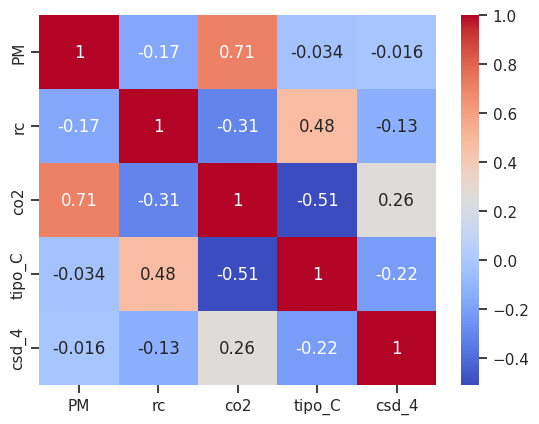

In [330]:
corr = X2.drop(columns='const').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [331]:
print("Variáveis com possível multicolinearidade (VIF):\n")

for variavel, valor in vif2.items():

    if variavel != 'const':

        if valor >10:
            nivel = "SEVERA"
        elif valor > 5 and valor <= 10:
            nivel = "ALTA"

        elif valor <=5 and valor > 1:
            nivel = "MODERADA"

        elif valor <= 1.001:   #Esta assim para evitar erros de arredondamento
            nivel = "NENHUMA"
        elif valor < 0.99:
            nivel = "VALOR INESPERADO" #Mesmo esquema aqui
        else:
            nivel = "Erro no processamento!"

        print(f"{variavel}: VIF = {valor:.2f} --> {nivel}")

Variáveis com possível multicolinearidade (VIF):

PM: VIF = 3.20 --> MODERADA
rc: VIF = 1.36 --> MODERADA
co2: VIF = 4.34 --> MODERADA
tipo_C: VIF = 2.33 --> MODERADA
csd_4: VIF = 1.19 --> MODERADA


### Heterocedasticidade

In [332]:
# Teste de Breusch-Pagan/Cook-Weisberg para diagnóstico de heterocedasticidade

# Criação de função 'breusch_pagan_test' para o teste de Breusch-Pagan para
#a elaboração de diagnóstico de heterocedasticidade


def breusch_pagan_test(modelo):

    df = pd.DataFrame({'yhat':modelo.fittedvalues,
                       'resid':modelo.resid})

    df['up'] = (np.square(df.resid))/np.sum(((np.square(df.resid))/df.shape[0]))

    modelo_aux = sm.OLS.from_formula('up ~ yhat', df).fit()

    anova_table = sm.stats.anova_lm(modelo_aux, typ=2)

    anova_table['sum_sq'] = anova_table['sum_sq']/2

    chisq = anova_table['sum_sq'].iloc[0]

    p_value = 1 - stats.chi2.cdf(chisq, 1)

    print(f"chisq: {chisq}")

    print(f"p-value: {p_value}")

    return chisq, p_value

#### Modelo Completo

In [333]:
# Teste de Breusch-Pagan propriamente dito

stat, p = breusch_pagan_test(model)

# H0 do teste: ausência de heterocedasticidade no modelo estimado
# H1 do teste: existência de heterocedasticidade no modelo estimado

# Interpretação
print('Statistics=%.6f, p-value=%.7f' % (stat, p))
alpha = 0.05 #nível de significância
if p > alpha:
	print('Não se rejeita H0')
else:
	print('Rejeita-se H0')

chisq: 3.976888974737858
p-value: 0.04612868660421099
Statistics=3.976889, p-value=0.0461287
Rejeita-se H0


Após aplicar o teste de Breusch-Pagan no modelo completo, o p-value obtido é de 0.0462, menor que 5%. Logo rejeita-se a hipótese nula, indicando a presença de heterocedasticidade nos resíduos do modelo.

#### Modelo após stepwise

In [334]:
# Teste de Breusch-Pagan propriamente dito

stat, p = breusch_pagan_test(stepwise_model)

# H0 do teste: ausência de heterocedasticidade no modelo estimado
# H1 do teste: existência de heterocedasticidade no modelo estimado

# Interpretação
print('Statistics=%.6f, p-value=%.7f' % (stat, p))
alpha = 0.05 #nível de significância
if p > alpha:
	print('Não se rejeita H0')
else:
	print('Rejeita-se H0')

chisq: 2.492208222327063
p-value: 0.11441109682082773
Statistics=2.492208, p-value=0.1144111
Não se rejeita H0


Após aplicar o teste de Breusch-Pagan no modelo após o procedimento stepwise, o p-value obtido é de 0.1142, maior que 5%. Logo não rejeita a hipótese nula e indica que a nova seleção de variáveis contribuiu significamente nas propriedades do modelo.

### Prevendo valores de MPG para dados faltantes no começo do dataset

In [335]:

print('Linhas excluídas por mpg ausente:')
display(invalid_mpg)

invalid_mpg.loc[invalid_mpg['rc'].isnull(), 'rc'] = rc_mean
invalid_mpg = invalid_mpg.drop(columns=['Modelo do carro', 'cfab'])
invalid_mpg = pd.get_dummies(
    invalid_mpg,
    columns=['tipo', 'csd'],
    drop_first=False,
    dtype=int
)

for col in ['tipo_T', 'csd_R']:
    if col in invalid_mpg.columns:
        del invalid_mpg[col]

predictors = [
    name.replace("Q('", "").replace("')", "")
    for name in stepwise_model.model.exog_names
    if name not in ("Intercept", "const")
]

for col in predictors:
    if col not in invalid_mpg.columns:
        invalid_mpg[col] = 0

invalid_mpg = invalid_mpg[predictors]
invalid_mpg['predicted_mpg'] = stepwise_model.predict(invalid_mpg)

print('Previsões de mpg para as linhas excluídas:')
display(invalid_mpg[['predicted_mpg']])

Linhas excluídas por mpg ausente:


,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg
9,20,LIBERTY/CHEROKEE 4WD,T,210,4,9.2,3.73,31.2,0.003,317,NaN
13,20,PT CRUISER,T,220,F,9.5,2.69,37.3,0.002,260,NaN


Previsões de mpg para as linhas excluídas:


,predicted_mpg
9,25.917929
13,31.620902


## Conclusão

In [336]:
stepwise_model.summary(title='Sumário do modelo final após stepwise')

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Sumário do modelo final após stepwise                     
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     72.54
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           4.95e-09
Time:                        19:41:18   Log-Likelihood:                -28.233
No. Observations:                  19   AIC:                             68.47
Df Residuals:                      13   BIC:                             74.13
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      22.6883      8.418      2.695      0.018       4.503      40.873
Q('PM')        -0.0236      0.005     -4.716      0.000      -0.034      -0.013
Q('rc')         2.3702      0.879      2.697      0.018       0.472       4.269
Q('co2')       -0.0322      0.010     -3.085      0.009      -0.055      -0.010
Q('tipo_C')     3.3593      0.973      3.453      0.004       1.257       5.461
Q('csd_4')     -3.3906      0.695     -4.880      0.000      -4.892      -1.890
==============================================================================
Omnibus:                        0.154   Durbin-Watson:                   2.247
Prob(Omnibus):                  0.926   Jarque-Bera (JB):                0.307
Skew:                          -0.172   Prob(JB):                        0.858
Kurtosis:                       2.480   Cond. No.                     1.16e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Analise de Componentes Principais

## Tratamento e limpeza dos dados

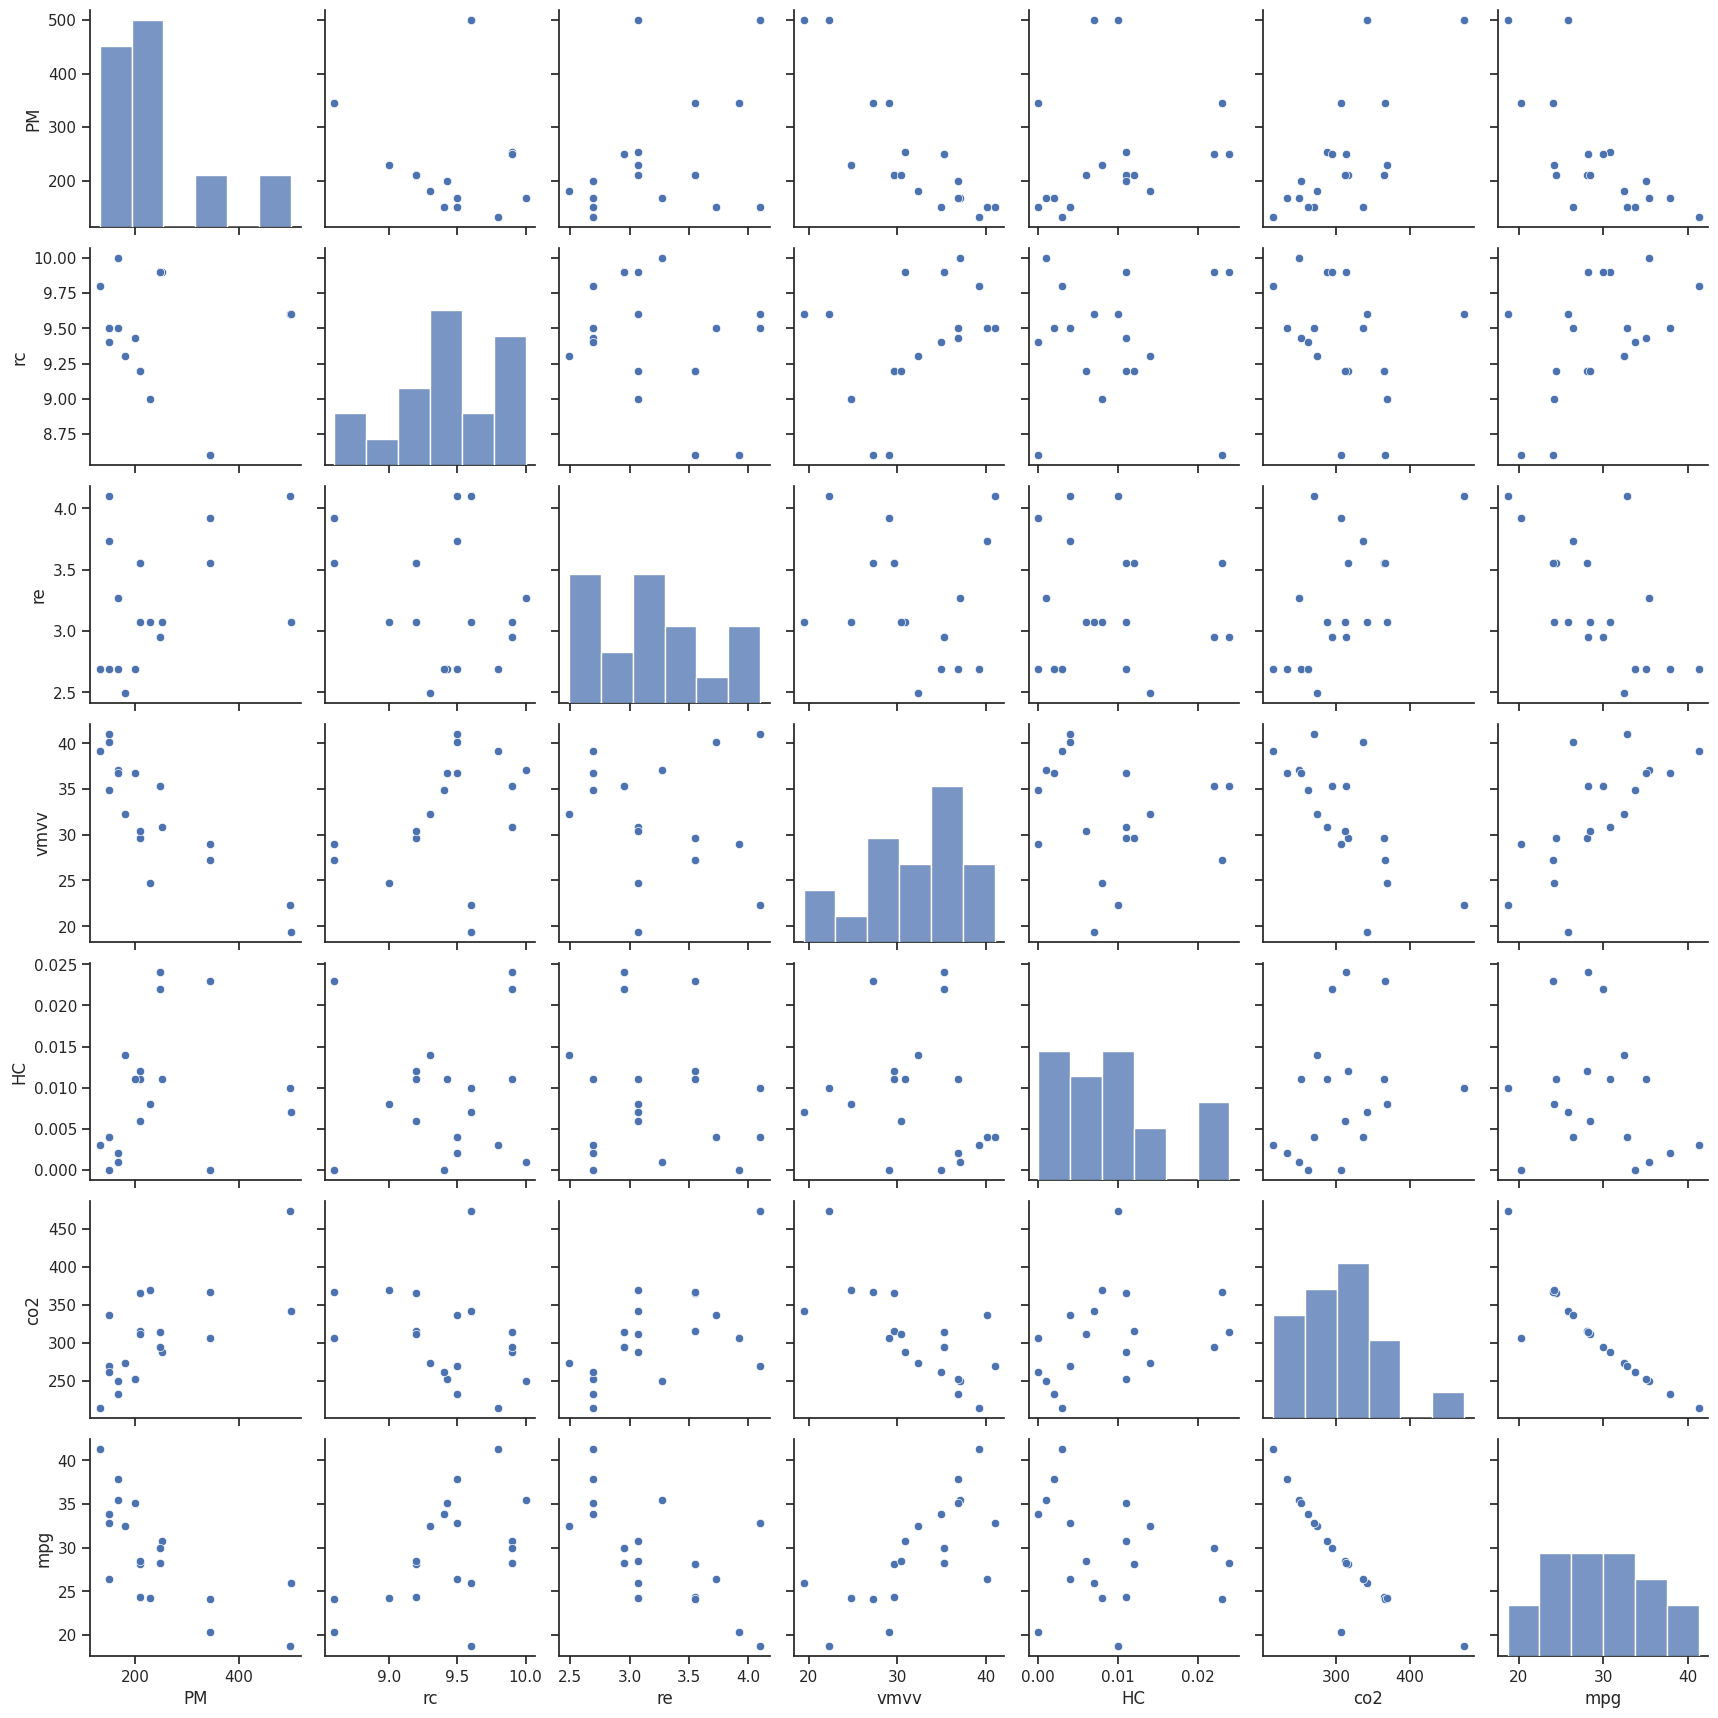

In [337]:
df = pd.read_excel('dataset.xlsx')  

#Retirando todas as linhas o com valor de mpg nulo
df = df.dropna(subset=['mpg'])

#substituir o valor do rc faltante pela média de suas váriaveis
rc_mean = df[df['rc'].notnull()]['rc'].mean()
df.loc[df['rc'].isnull(), 'rc'] = rc_mean

#Substituido um valor de co2 impossivel de ser feito
co2_mean = int(round(df[df['co2'] != 0]['co2'].mean()))
df.loc[df['co2'] == 0, 'co2'] = co2_mean

#Removendo a variavel que queremos medir
df.set_index('Modelo do carro', inplace=True)

tipos_salvos = df['tipo'].copy()

# Colunas nao importantes para a analise que serao removida
colunas_removidas = ['cfab', 'csd', 'tipo']
df = df.drop(columns = colunas_removidas)

# Verificando se as variaveis são correlacionadas

sns.set(style='ticks')
sns.pairplot(df)



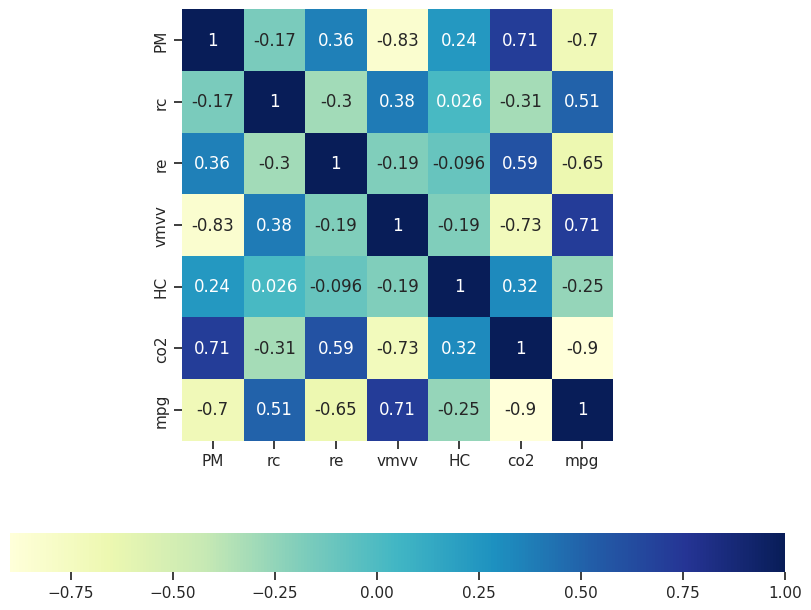

In [338]:
plt.figure(figsize=(10,8))
ax=sns.heatmap(df.corr(),
               annot=True,
               cmap='YlGnBu',
               cbar_kws={"orientation":"horizontal"})
ax.set_aspect("equal")

In [339]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA()
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    pca_result, 
    columns=[f'CP{i+1}' for i in range(pca_result.shape[1])],
    index=df.index # Mantém os nomes dos carros nas linhas!
)

print("Dados prontos e transformados em Componentes Principais:")
print(df_pca.head())

Dados prontos e transformados em Componentes Principais:
                         CP1       CP2       CP3       CP4       CP5  \
Modelo do carro                                                        
300C/SRT-8          0.493311  0.906723  0.586367 -0.512232  0.011180   
CARAVAN 2WD         1.072262  0.951744 -1.253018  0.296094 -0.209391   
CROSSFIRE ROADSTER  2.112763 -0.481034  1.120036 -0.753231  0.023697   
DAKOTA PICKUP 2WD  -0.650396 -0.300904 -0.193521  0.608362  0.038176   
DAKOTA PICKUP 4WD  -1.333002 -0.407614  0.004084  0.670975 -0.633317   

                         CP6       CP7  
Modelo do carro                         
300C/SRT-8          0.050177 -0.400557  
CARAVAN 2WD        -0.043844 -0.002833  
CROSSFIRE ROADSTER  0.132219 -0.227684  
DAKOTA PICKUP 2WD   0.481938 -0.392004  
DAKOTA PICKUP 4WD   0.173644 -0.159037  


In [340]:
print("Explicação da variância por componente principal:")
eigenvalues = pca.explained_variance_
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i in range(len(eigenvalues)):
    print(f"CP{i+1}: Autovalor = {eigenvalues[i]:.3f}, Variância = {explained_variance[i]:.1%}, Acumulada = {cumulative_variance[i]:.1%}")


Explicação da variância por componente principal:
CP1: Autovalor = 4.089, Variância = 55.3%, Acumulada = 55.3%
CP2: Autovalor = 1.273, Variância = 17.2%, Acumulada = 72.6%
CP3: Autovalor = 0.849, Variância = 11.5%, Acumulada = 84.1%
CP4: Autovalor = 0.801, Variância = 10.8%, Acumulada = 94.9%
CP5: Autovalor = 0.233, Variância = 3.1%, Acumulada = 98.1%
CP6: Autovalor = 0.083, Variância = 1.1%, Acumulada = 99.2%
CP7: Autovalor = 0.061, Variância = 0.8%, Acumulada = 100.0%


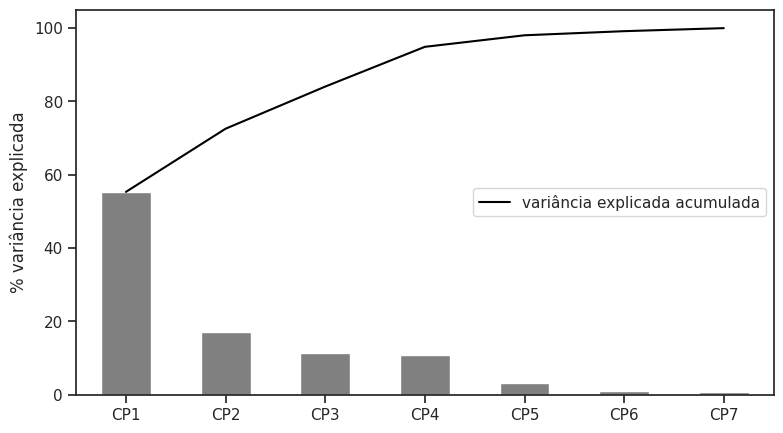

In [341]:
tot = sum(pca.explained_variance_)
var_exp = [(i / tot)*100 for i in sorted(pca.explained_variance_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)


cp =['CP'+str(i+1) for i in range(len(pca.components_))]

df_grafico = pd.DataFrame({'cp': cp, 'var_exp': var_exp, 'cum_var_exp': cum_var_exp})

fig, ax = plt.subplots(figsize=(9,5))
df_grafico.plot.bar('cp', 'var_exp', color='gray', ax=ax, legend=False)
df_grafico.plot.line('cp', 'cum_var_exp', color='black', ax=ax)
plt.legend(labels=['variância explicada acumulada'],
           loc='center right',)
plt.ylabel('% variância explicada')
plt.xlabel('');

In [342]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'CP{i+1}' for i in range(pca.n_components_)],
    index=df.columns
)

components = loadings.iloc[:, :2]

print(np.round(loadings.iloc[:, :2], 3))

        CP1    CP2
PM   -0.425  0.227
rc    0.250  0.420
re   -0.311 -0.495
vmvv  0.426 -0.185
HC   -0.146  0.694
co2  -0.471  0.056
mpg   0.485  0.091


In [343]:
for component in components.columns:
    print(f"Componente {component}:")
    sorted_loadings = components[component].abs().sort_values(ascending=False)
    for variable in sorted_loadings.index:
        loading_value = components.loc[variable, component]
        if abs(loading_value) > 0.3:  # Considerando apenas loadings significativos
            print(f"  {variable}: {loading_value:.3f}")

Componente CP1:
  mpg: 0.485
  co2: -0.471
  vmvv: 0.426
  PM: -0.425
  re: -0.311
Componente CP2:
  HC: 0.694
  re: -0.495
  rc: 0.420


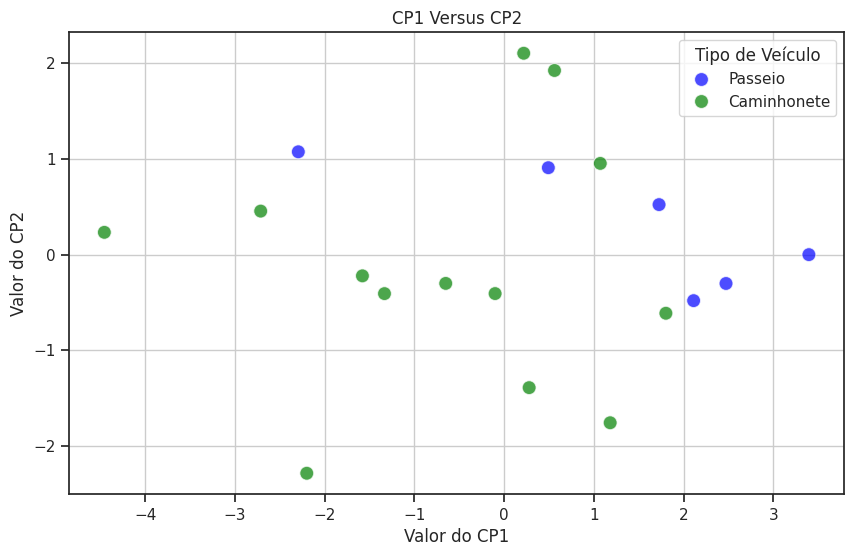

In [344]:
# Cria o DataFrame com as componentes principais
df_final = df_pca[['CP1', 'CP2']].copy()

# 1. Adiciona a coluna salva dando o nome de 'Categoria'
df_final['Categoria'] = tipos_salvos

# 2. Faz o mapeamento usando a coluna 'Categoria' (e não 'tipo'!)
df_final['Categoria'] = df_final['Categoria'].map({'C': 'Passeio', 'T': 'Caminhonete'})


cores_personalizadas = {'Passeio': 'blue', 'Caminhonete': 'green'}

plt.figure(figsize=(10,6))

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_final, 
    x='CP1', 
    y='CP2', 
    hue='Categoria',          
    palette=cores_personalizadas, 
    s=100,                    
    alpha=0.7                 
)

plt.title('CP1 Versus CP2')
plt.xlabel('Valor do CP1')
plt.ylabel('Valor do CP2')
plt.grid(True)
plt.legend(title='Tipo de Veículo', loc='upper right')
plt.show()